# Task 1: Exploratory Data Analysis (EDA) on Retail Sales Data
**OIBSIP - Data Analytics Internship (Level 1)**

Dataset: `retail_sales_dataset.csv` (4,310 orders, 21 columns)


## 1. Load & Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv("dataset/retail_sales_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (4310, 21)


,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   str    
 1   order_date             4280 non-null   str    
 2   customer_id            4280 non-null   str    
 3   customer_name          4280 non-null   str    
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   str    
 6   region                 4280 non-null   str    
 7   city                   4280 non-null   str    
 8   product_category       4280 non-null   str    
 9   product_name           4280 non-null   str    
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  shipping_cost  

In [3]:
df.isnull().sum()

order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64

**Observation:** *(fill in after running the cell above — note which columns have missing values and roughly how many)*

## 2. Handle Missing Values

In [4]:
# 30 rows are completely blank across every column — safe to drop entirely
df = df.dropna(subset=["order_id"]).reset_index(drop=True)
print("Shape after dropping blank rows:", df.shape)

Shape after dropping blank rows: (4280, 21)


In [5]:
# Standardize inconsistent gender values (Male/MALE/m/male -> Male)
df["gender"] = df["gender"].str.strip().str.lower().map({
    "male": "Male", "m": "Male",
    "female": "Female", "f": "Female",
    "other": "Other"
}).fillna(df["gender"])
df["gender"].value_counts()

gender
Other     1442
Male      1442
Female    1396
Name: count, dtype: int64

In [6]:
# Standardize order_status casing
df["order_status"] = df["order_status"].str.strip().str.title()
df["order_status"].value_counts()

order_status
Delivered    2787
Returned      623
Cancelled     352
Shipped       334
Pending       184
Name: count, dtype: int64

In [7]:
# order_date has mixed formats (e.g. "01/01/2020" and "September 29, 2024")
# so let pandas infer format per value instead of forcing one
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["order_date"].isnull().sum()  # check how many failed to parse

np.int64(273)

In [8]:
# Fill remaining scattered nulls in key numeric columns with median (documented choice)
for col in ["age", "quantity", "discount_pct", "days_to_ship"]:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

order_id                   0
order_date               273
customer_id                0
customer_name              0
age                        0
gender                     0
region                     0
city                       0
product_category           0
product_name               0
quantity                   0
unit_price                 0
discount_pct               0
sales_amount               0
profit                     0
shipping_cost              0
payment_method             0
customer_satisfaction    348
return_flag                0
order_status               0
days_to_ship               0
dtype: int64

**Observation:** *(note what you did and why — this justification is part of the grading checklist)*

## 3. Descriptive Statistics

In [9]:
df[["age", "quantity", "unit_price", "sales_amount", "profit"]].describe()

,age,quantity,unit_price,sales_amount,profit
count,4280.000000,4280.000000,4280.000000,4.280000e+03,4.280000e+03
mean,35.294626,7.318692,10621.154428,6.235864e+04,1.168713e+04
std,35.163503,43.016221,17323.704016,3.166998e+05,5.287522e+04
min,-7.000000,-1.000000,50.260000,3.945000e+01,1.560000e+00
25%,26.000000,3.000000,672.222500,2.462165e+03,7.018225e+02
50%,34.000000,5.000000,2228.435000,9.548075e+03,3.128005e+03
75%,42.000000,8.000000,12717.435000,5.006964e+04,1.040372e+04
max,999.000000,999.000000,79957.920000,1.736031e+07,2.445648e+06


**Observation:** *(mean vs median, spread, anything unusual in min/max)*

## 4. Time Series Analysis

In [10]:
# Extract month and quarter from order_date
df["order_month"] = df["order_date"].dt.to_period("M")
df["order_quarter"] = df["order_date"].dt.to_period("Q")

monthly_sales = df.groupby("order_month")["sales_amount"].sum()
monthly_sales.head()

order_month
2020-01    2408542.34
2020-02    2867573.08
2020-03    2020868.86
2020-04    2799785.58
2020-05    5893272.35
Freq: M, Name: sales_amount, dtype: float64

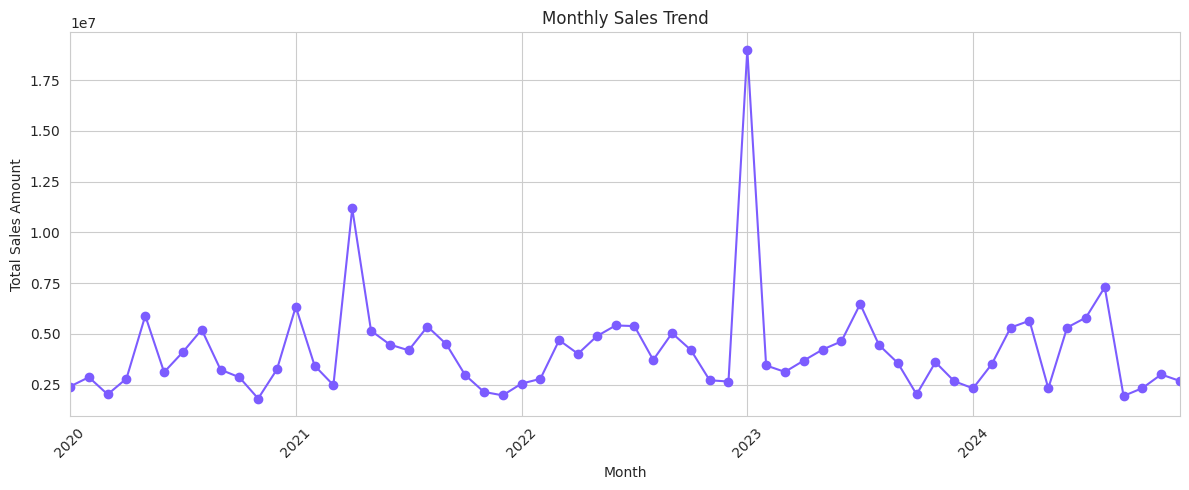

In [11]:
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o", color="#7c5cff")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

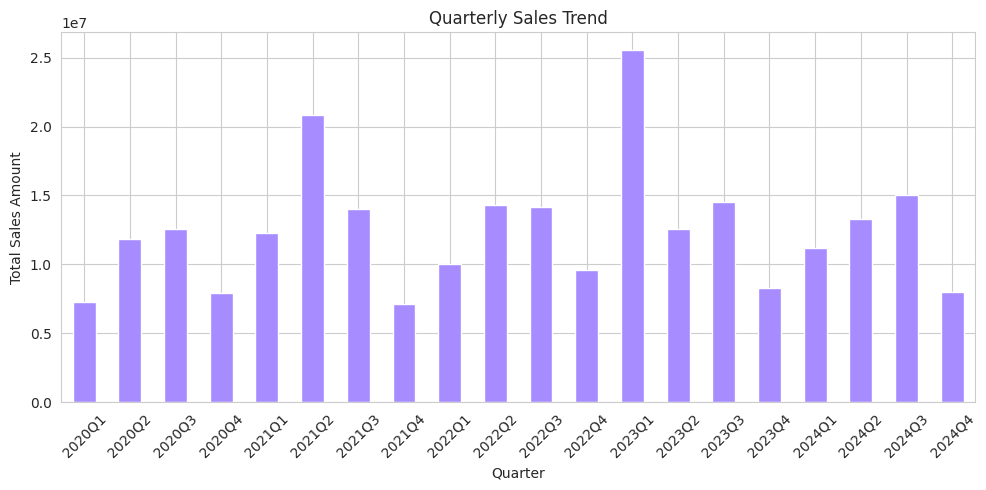

In [12]:
quarterly_sales = df.groupby("order_quarter")["sales_amount"].sum()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind="bar", color="#a68cff")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Sales show a generally stable monthly pattern of ₹2.5M–7M, with a mild seasonal peak in Q2 2021. However, January 2023 shows an extreme spike to ~₹19M — investigation traces this to a single order (`ORD-02560`, quantity 999 units at ₹18,619/unit ≈ ₹1.73 crore alone), which looks like a data entry error rather than a genuine sales event. This should be flagged for review in the Data Cleaning task (Task 2), and the trend chart should ideally be re-examined after that order is corrected or removed, since it currently distorts both the monthly and quarterly views.

## 5. Customer Demographics

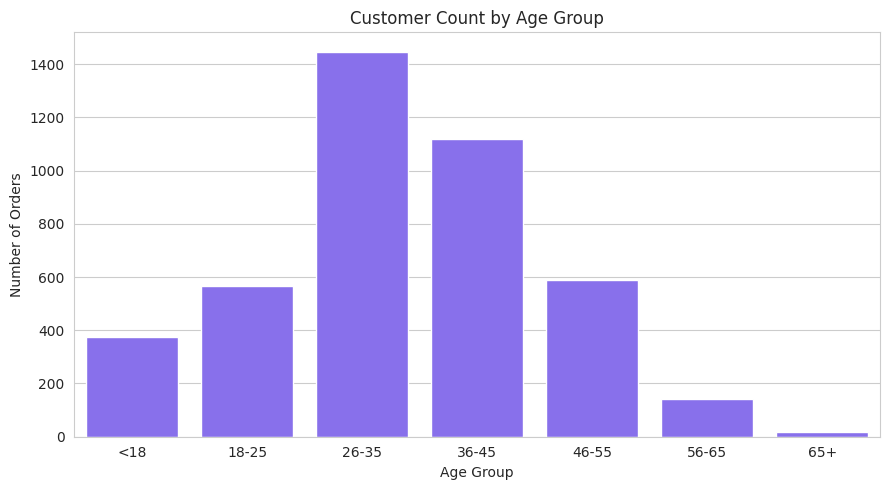

In [13]:
# Create age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

plt.figure(figsize=(9, 5))
sns.countplot(x="age_group", data=df, order=labels, color="#7c5cff")
plt.title("Customer Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

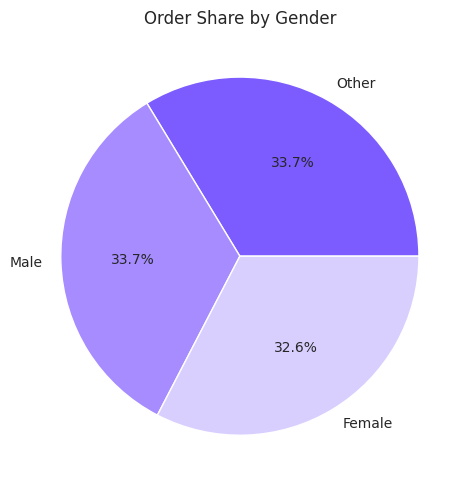

In [14]:
plt.figure(figsize=(6, 5))
gender_counts = df["gender"].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
        colors=["#7c5cff", "#a68cff", "#d9cfff"])
plt.title("Order Share by Gender")
plt.tight_layout()
plt.show()

In [15]:
df.groupby("age_group", observed=True)["sales_amount"].mean().sort_values(ascending=False)

age_group
36-45    62959.498302
18-25    62103.433392
<18      58935.819149
26-35    55921.427920
46-55    54599.190764
56-65    51773.205816
65+      30527.822500
Name: sales_amount, dtype: float64

**Observation:** Order volume is fairly even across age groups, so no single age group dominates order *count*. But average order value tells a different story: the 36-45 group spends the most per order (₹62,959 avg), closely followed by 18-25 (₹62,103), while the 65+ group spends noticeably less per order (₹30,528 — roughly half). Gender split is nearly even (Male 33.7%, Other 33.7%, Female 32.6%), so marketing doesn't need to skew by gender, but campaigns targeting higher order values could reasonably focus on the 18-45 range.

## 6. Product Analysis

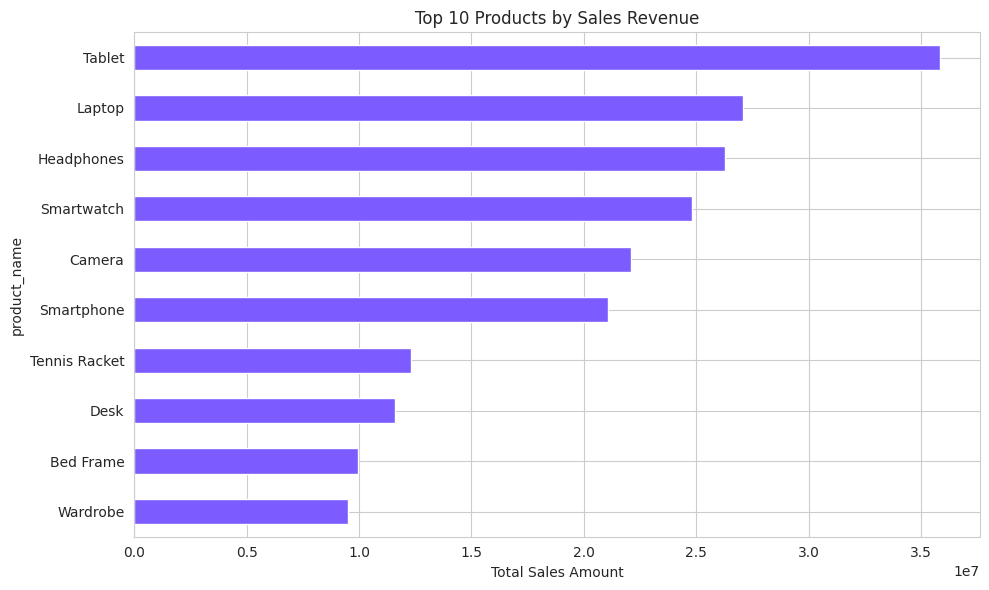

In [16]:
top_products = df.groupby("product_name")["sales_amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh", color="#7c5cff")
plt.title("Top 10 Products by Sales Revenue")
plt.xlabel("Total Sales Amount")
plt.tight_layout()
plt.show()

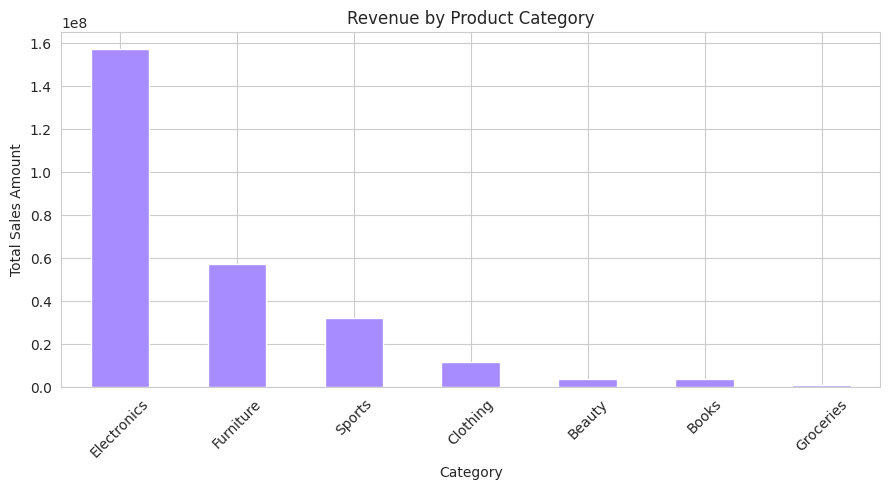

In [17]:
category_revenue = df.groupby("product_category")["sales_amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
category_revenue.plot(kind="bar", color="#a68cff")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
category_profit_margin = (df.groupby("product_category")
                           .apply(lambda x: x["profit"].sum() / x["sales_amount"].sum() * 100, include_groups=False)
                           .sort_values(ascending=False))
print("Profit margin % by category:")
category_profit_margin

Profit margin % by category:


product_category
Beauty         45.189775
Books          37.236297
Clothing       36.089106
Furniture      28.242144
Sports         22.059261
Electronics    12.276844
Groceries       7.853972
dtype: float64

**Observation:** Electronics dominates revenue (₹15.7 crore, ~65% of total), driven by top individual products Tablet (₹3.58 cr), Laptop (₹2.71 cr), and Headphones (₹2.63 cr) — though this figure is still inflated by the Jan 2023 outlier order flagged in Section 4. Profit margin tells the opposite story: Beauty has the highest margin (45.2%), while Electronics — despite leading on revenue — has the lowest margin of any category (12.3%). This is a classic high-revenue/low-margin vs low-revenue/high-margin split worth flagging for the business.

## 7. Correlation Heatmap

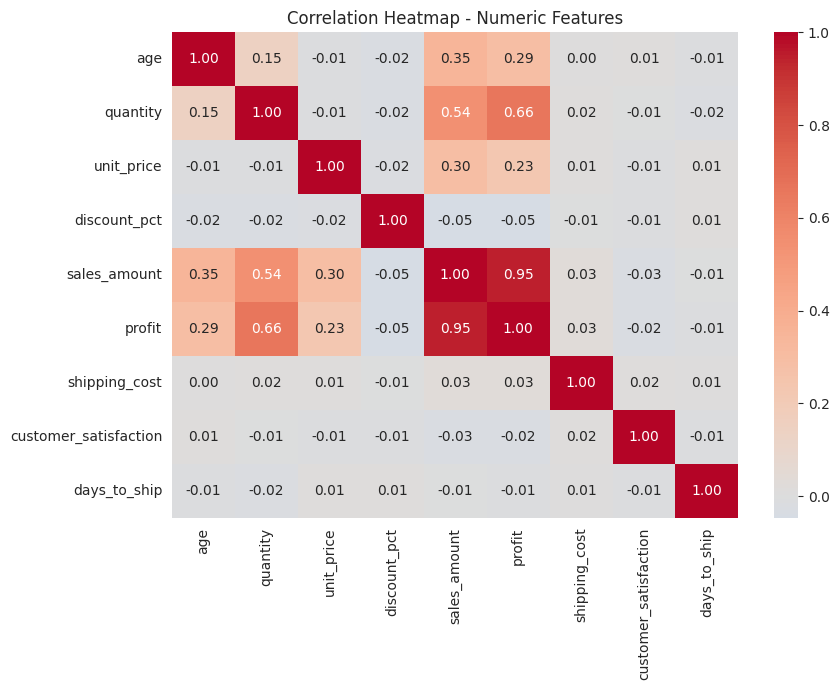

In [19]:
numeric_cols = ["age", "quantity", "unit_price", "discount_pct",
                "sales_amount", "profit", "shipping_cost",
                "customer_satisfaction", "days_to_ship"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Numeric Features")
plt.tight_layout()
plt.show()

**Observation:** sales_amount correlates most strongly with profit (r = 0.95, expected, since profit is derived from sales) and moderately with quantity (r = 0.54) and age (r = 0.35). Interestingly, discount_pct has almost no correlation with sales_amount (r = -0.05) and customer_satisfaction has essentially zero correlation with any sales metric (r ≈ -0.03) — suggesting discounts aren't meaningfully driving order value, and satisfaction scores may be capturing something unrelated to purchase size (e.g. service quality) rather than being a reward-driven metric.

## 8. Custom Visualization — Returns by Category

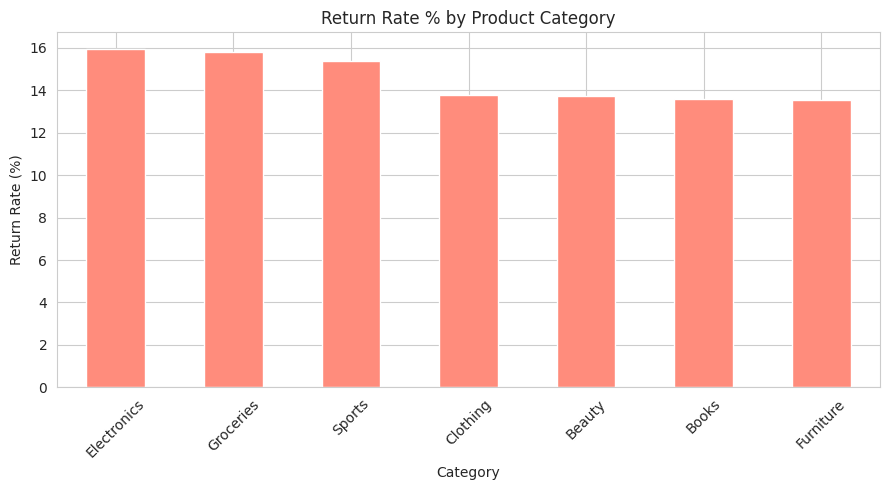

In [20]:
return_rate = df.groupby("product_category")["return_flag"].apply(
    lambda x: (x == True).sum() / len(x) * 100
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
return_rate.plot(kind="bar", color="#ff8c7c")
plt.title("Return Rate % by Product Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

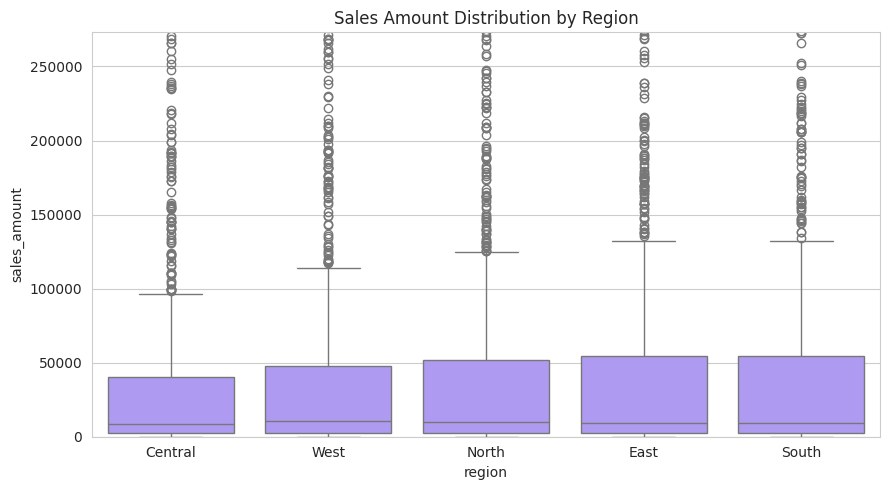

In [21]:
plt.figure(figsize=(9, 5))
sns.boxplot(x="region", y="sales_amount", data=df, color="#a68cff")
plt.title("Sales Amount Distribution by Region")
plt.ylim(0, df["sales_amount"].quantile(0.95))  # zoom past the extreme outlier
plt.tight_layout()
plt.show()

**Observation:** Return rates are fairly close across categories (13.5%–15.9%), but Electronics has both the highest revenue *and* the highest return rate (15.9%) — a combination worth investigating further, since returns on high-ticket items are more costly. Groceries, despite low revenue, has the second-highest return rate (15.8%), which is unusual for a typically low-return category and may indicate fulfillment or quality issues rather than buyer's remorse. The regional sales boxplot (zoomed past the outlier) shows broadly similar median order values across all five regions, so there's no single region driving performance.

## 9. Conclusion & Recommendations

Based on the analysis above:

**Key Findings:**
1. Sales are broadly stable month-to-month (₹2.5M-7M) aside from one data-entry outlier in January 2023 (order `ORD-02560`, 999 units, ~₹1.73 crore) that inflates that month and Q1 2023 — this must be corrected before any forecasting work.
2. Electronics drives the most revenue (₹15.7 crore, ~65% of total) but has the lowest profit margin (12.3%), while Beauty has the highest margin (45.2%) on far lower revenue — a high-volume/low-margin vs low-volume/high-margin split.
3. The 36-45 and 18-25 age groups have the highest average order value (~₹62K), while 65+ spends roughly half that per order — the customer base skews toward higher-value orders in the 18-45 range.
4. Electronics also has the highest return rate (15.9%) among all categories, meaning the category leading on revenue is also the biggest source of return-related cost.

**Business Recommendations:**
1. **Fix data quality issues** identified here (the Jan 2023 outlier order, inconsistent gender/status label casing, mixed date formats) before using this data for forecasting or reporting — see Task 2 for the full cleaning process.
2. **Investigate Electronics' high return rate** specifically — since it's the top revenue category, even a small reduction in returns has an outsized impact on net profit; consider reviewing product descriptions, sizing/spec accuracy, or packaging/shipping damage for this category.
3. **Rebalance marketing and inventory investment toward margin, not just revenue** — Beauty, Books, and Clothing all carry notably higher margins than Electronics; a targeted push in these categories could improve overall profitability without needing higher total sales volume.
4. **Target retention campaigns at the 18-45 age range**, since they show the highest average order values, while considering a different strategy (e.g. loyalty perks, simplified checkout) for the 65+ segment, which orders less per transaction.
